In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#training image preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 43444 files belonging to 38 classes.


#validation image preprocessing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10861 files belonging to 38 classes.


#  Building model

In [5]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [6]:
model = Sequential()

In [7]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [8]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [9]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Dropout(0.25))

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(units=1500,activation='relu'))

In [15]:
model.add(Dropout(0.40))

In [16]:
model.add(Dense(units=38,activation='softmax'))

# Compiling model

In [17]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

Model Training


In [19]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
1358/1358 [==============================] - 2605s 2s/step - loss: 1.4330 - accuracy: 0.5930 - val_loss: 0.5796 - val_accuracy: 0.8233
Epoch 2/10
1358/1358 [==============================] - 2531s 2s/step - loss: 0.5651 - accuracy: 0.8221 - val_loss: 0.4106 - val_accuracy: 0.8676
Epoch 3/10
1358/1358 [==============================] - 2555s 2s/step - loss: 0.3480 - accuracy: 0.8887 - val_loss: 0.2922 - val_accuracy: 0.9048
Epoch 4/10
1358/1358 [==============================] - 2542s 2s/step - loss: 0.2458 - accuracy: 0.9190 - val_loss: 0.2151 - val_accuracy: 0.9319
Epoch 5/10
1358/1358 [==============================] - 2513s 2s/step - loss: 0.1771 - accuracy: 0.9415 - val_loss: 0.2251 - val_accuracy: 0.9302
Epoch 6/10
1358/1358 [==============================] - 2484s 2s/step - loss: 0.1413 - accuracy: 0.9530 - val_loss: 0.1750 - val_accuracy: 0.9473
Epoch 7/10
1358/1358 [==============================] - 2489s 2s/step - loss: 0.1203 - accuracy: 0.9605 - val_loss: 0.1567 -

Model Evaluation

In [20]:
train_loss,train_acc = model.evaluate(training_set)

1358/1358 [==============================] - 526s 387ms/step - loss: 0.0322 - accuracy: 0.9901


In [21]:
print(train_loss,train_acc)

0.03221974894404411 0.9900791645050049


In [22]:
val_loss,val_acc = model.evaluate(validation_set)

340/340 [==============================] - 123s 361ms/step - loss: 0.1657 - accuracy: 0.9518


In [23]:
print(val_loss,val_acc)

0.16569022834300995 0.9518460631370544


Saving the model

In [24]:
model.save("trained_model.keras")

In [25]:
model.save("trained_model.h5")

In [26]:
training_history.history

{'loss': [1.4330463409423828,
  0.5651097893714905,
  0.3479732573032379,
  0.24576054513454437,
  0.17713801562786102,
  0.14128029346466064,
  0.12028004229068756,
  0.09483722597360611,
  0.08110802620649338,
  0.07258708029985428],
 'accuracy': [0.5929702520370483,
  0.8221158385276794,
  0.8887303471565247,
  0.9190222024917603,
  0.9415339231491089,
  0.9530199766159058,
  0.9604548215866089,
  0.9687643647193909,
  0.974449872970581,
  0.9766365885734558],
 'val_loss': [0.5795869827270508,
  0.41062554717063904,
  0.2921983599662781,
  0.2151418775320053,
  0.22506698966026306,
  0.1750447303056717,
  0.15671846270561218,
  0.1621352881193161,
  0.18594896793365479,
  0.16569016873836517],
 'val_accuracy': [0.8233127593994141,
  0.8675996661186218,
  0.9047969579696655,
  0.9318662881851196,
  0.9302089810371399,
  0.9473345279693604,
  0.9526746869087219,
  0.950741171836853,
  0.946045458316803,
  0.9518460631370544]}

In [27]:
#record history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [28]:
print(training_history.history.keys())


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


# Accuracy Visualization

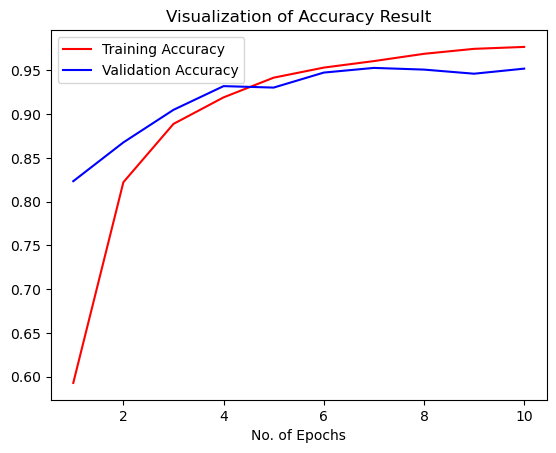

In [29]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [30]:
class_name = validation_set.class_names

In [31]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10861 files belonging to 38 classes.


In [32]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

10861/10861 [==============================] - 217s 20ms/step


In [33]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [34]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(10861,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [35]:
predicted_categories

<tf.Tensor: shape=(10861,), dtype=int64, numpy=array([19,  5,  0, ..., 37, 37, 37], dtype=int64)>

In [36]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [37]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.70      0.80       126
                                 Apple___Black_rot       0.88      0.98      0.93       125
                          Apple___Cedar_apple_rust       0.91      0.89      0.90        55
                                   Apple___healthy       0.96      0.90      0.93       329
                               Blueberry___healthy       0.95      0.99      0.97       300
          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.98       210
                 Cherry_(including_sour)___healthy       0.99      0.97      0.98       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.84      0.82       103
                       Corn_(maize)___Common_rust_       0.97      0.98      0.98       239
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.91      0.

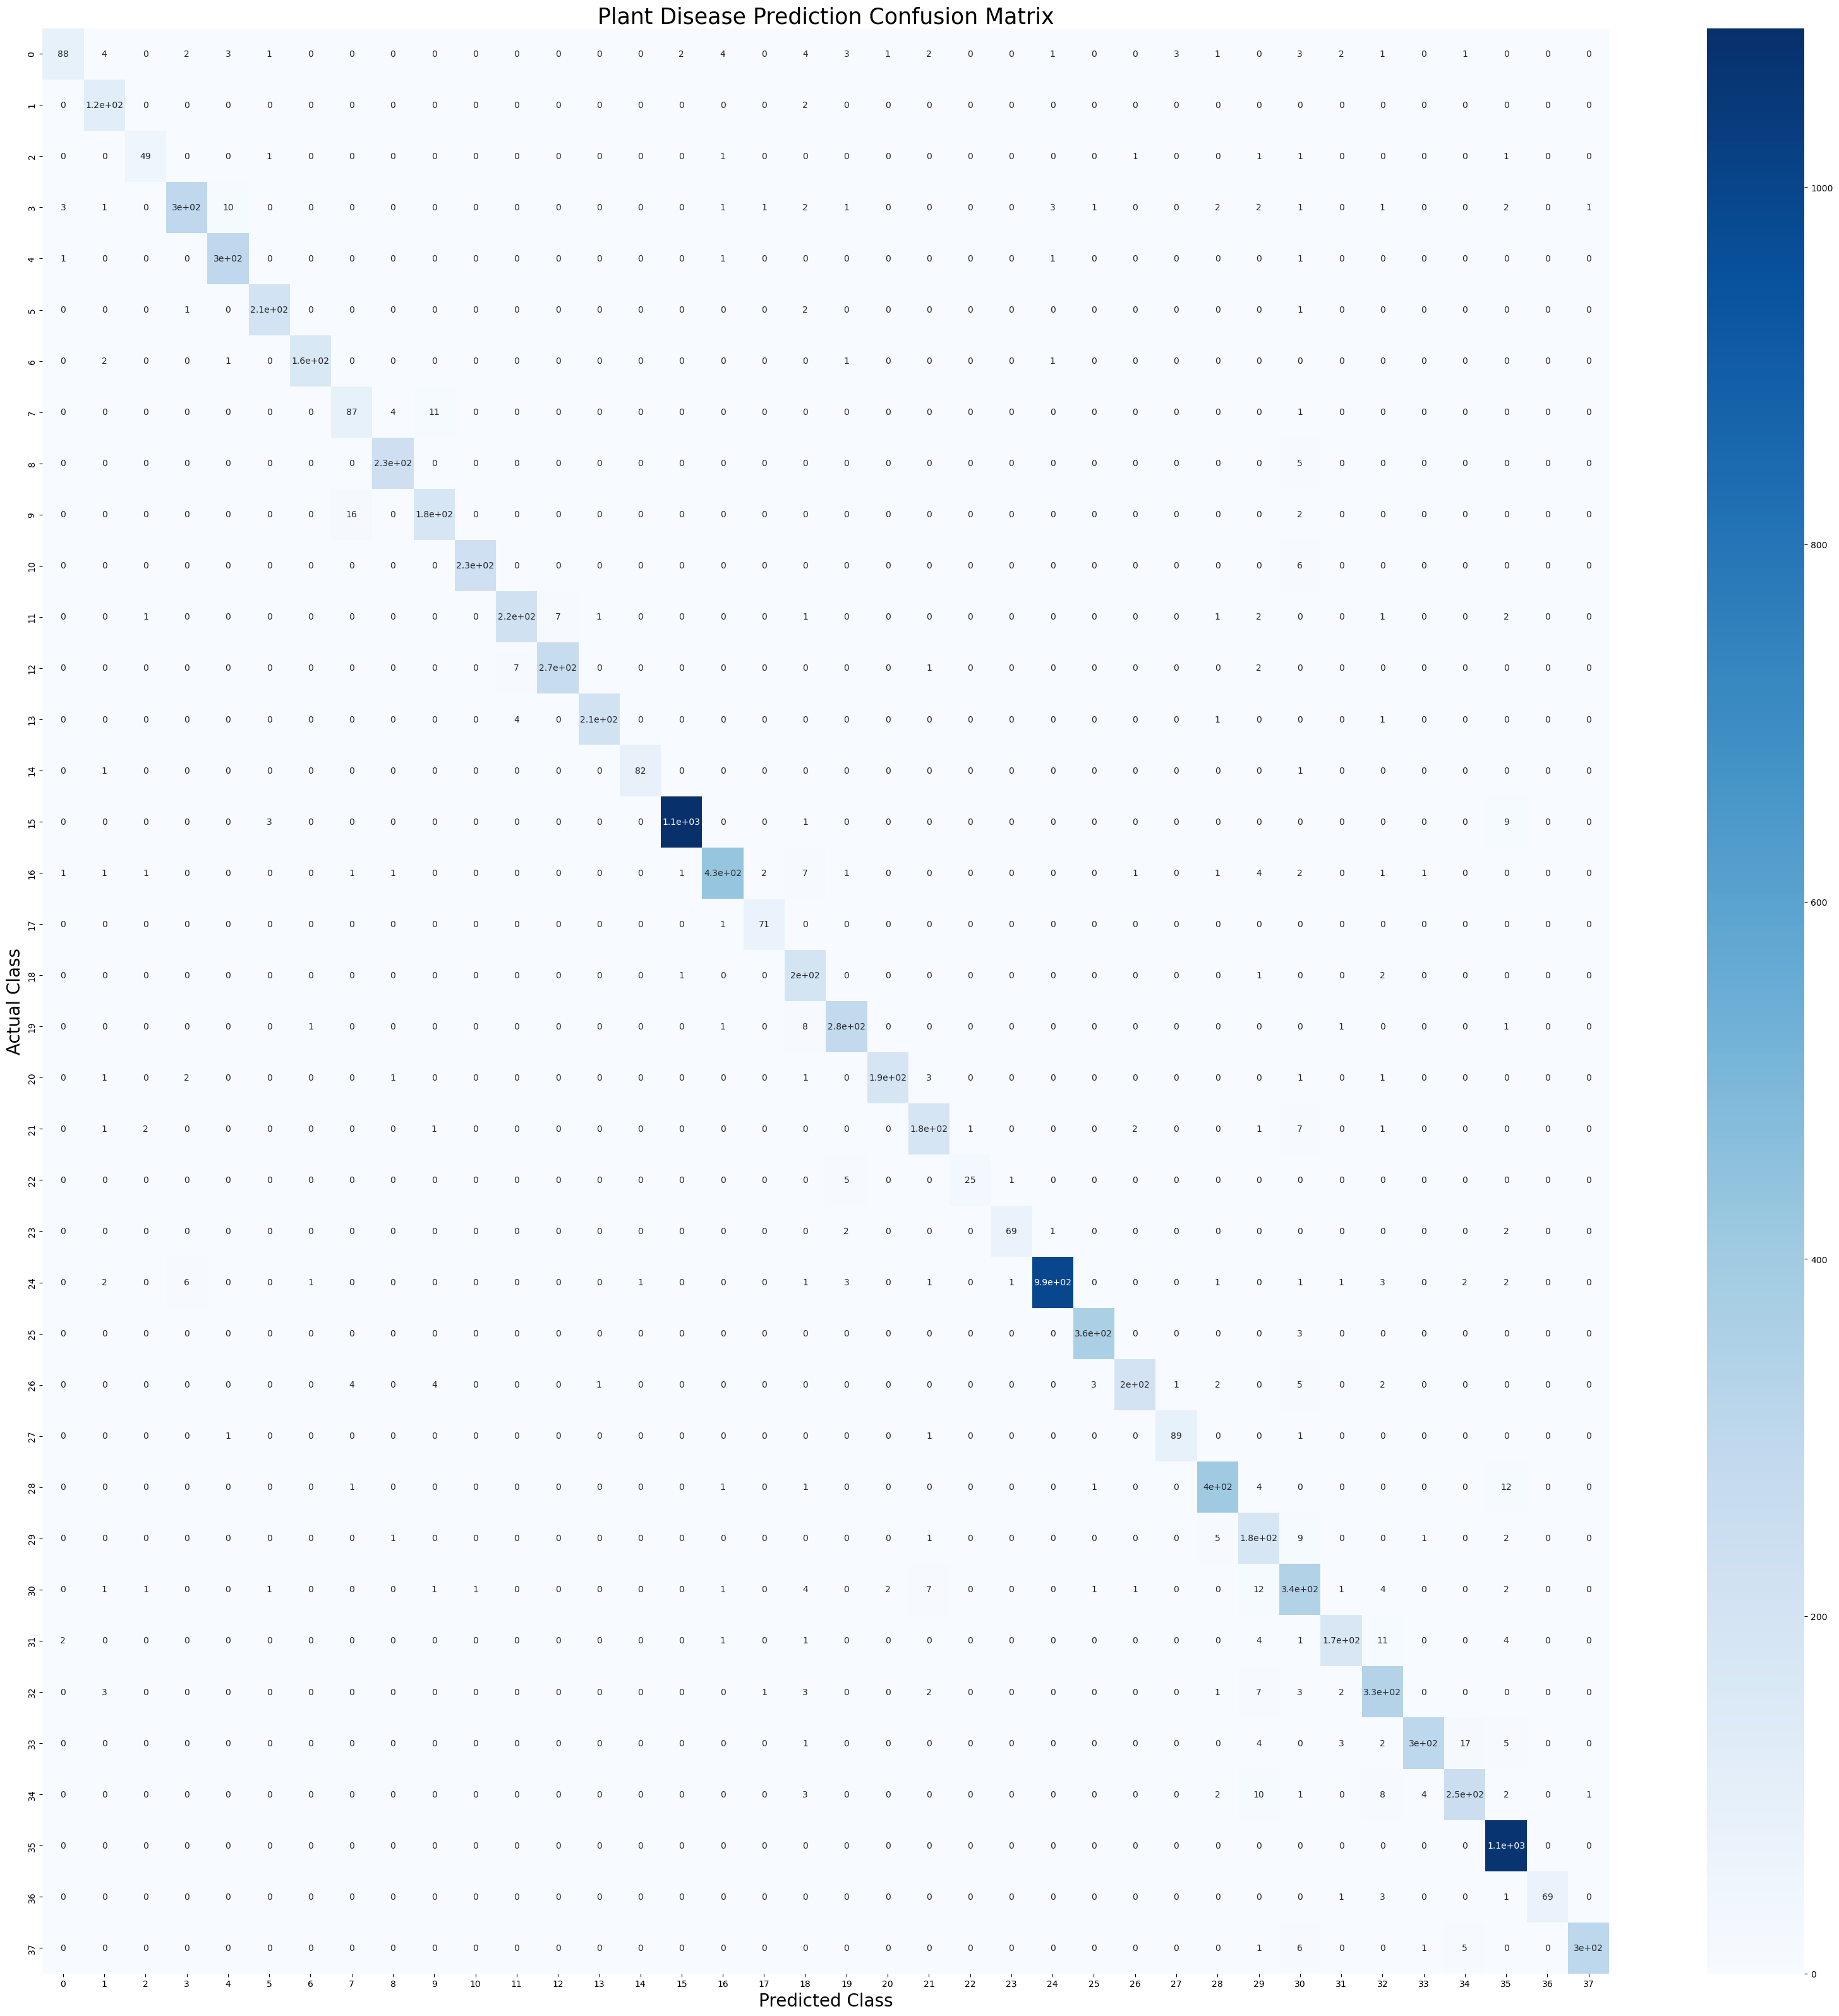

In [38]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10},cmap='Blues')

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()